## Project

In [1]:
from datasets import load_dataset

ds_tr = load_dataset("musabg/wikipedia-tr")

In [2]:
ds_tr = ds_tr['train'].select(range(100))

In [3]:
print("Türkçe dataset:", ds_tr)  

Türkçe dataset: Dataset({
    features: ['id', 'url', 'title', 'text'],
    num_rows: 100
})


### Chunking

In [4]:
import re
from nltk.tokenize import sent_tokenize, word_tokenize
import nltk

nltk.download('punkt')

# Sabit Uzunlukta Token
def chunk_by_word_count(text, max_words=225):
    words = word_tokenize(text)
    chunks = []
    for i in range(0, len(words), max_words):
        chunk = words[i:i+max_words]
        chunks.append(' '.join(chunk))
    return chunks

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Sadık\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [5]:
all_chunks_tr = []
for sample in ds_tr:
    text = sample['text']
    chunks = chunk_by_word_count(text)
    all_chunks_tr.extend(chunks)

print(f"Toplam chunk sayısı: {len(all_chunks_tr)}")

Toplam chunk sayısı: 1118


### TF-IDF + FAISS

In [6]:
import faiss
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

vectorizer = TfidfVectorizer(
    max_features=5000,    # istersen en fazla kullanılacak kelime sayısını sınırla
)


tfidf_embedding = vectorizer.fit_transform(all_chunks_tr)

tfidf_dense = tfidf_embedding.toarray().astype('float32')

# FAISS index oluştur (L2 uzaklığı için)
dimension_tfidf = tfidf_dense.shape[1]
index_tfidf = faiss.IndexFlatL2(dimension_tfidf)

# Vektörleri FAISS indexe ekle
index_tfidf.add(tfidf_dense)

print(f"TF-IDF FAISS indexinde toplam vektör sayısı: {index_tfidf.ntotal}")

TF-IDF FAISS indexinde toplam vektör sayısı: 1118


c:\Anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


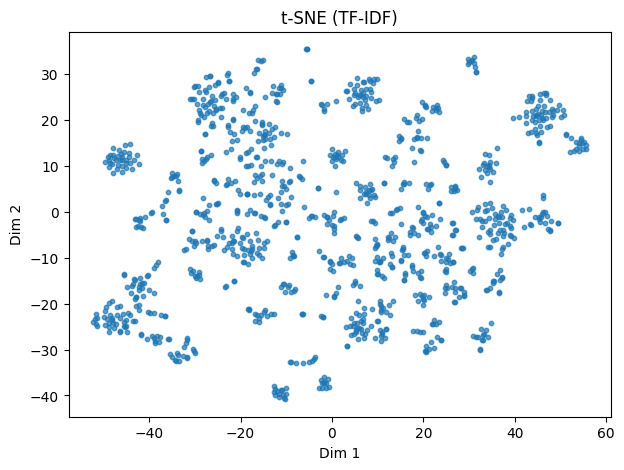

In [7]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne_tfidf = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tfidf_2d = tsne_tfidf.fit_transform(tfidf_embedding.toarray())

plt.figure(figsize=(7, 5))
plt.scatter(tfidf_2d[:, 0], tfidf_2d[:, 1], s=10, alpha=0.7)
plt.title("t-SNE (TF-IDF)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

### SBERT + FAISS

In [8]:
from sentence_transformers import SentenceTransformer

model_sbert = SentenceTransformer('all-MiniLM-L6-v2')  

embedding_sbert = model_sbert.encode(all_chunks_tr, show_progress_bar=True)

print(embedding_sbert.shape)  # (chunk sayısı, embedding boyutu)

W0814 13:13:42.164000 6840 torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.



Batches:   0%|          | 0/35 [00:00<?, ?it/s]

C:\Users\Sadık\AppData\Roaming\Python\Python312\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


(1118, 384)


In [9]:
import faiss
import numpy as np

dimension_sbert = embedding_sbert.shape[1]
index_sbert = faiss.IndexFlatL2(dimension_sbert)  # L2 mesafesine göre index
index_sbert.add(np.array(embedding_sbert))  # Vektörleri ekle

c:\Anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


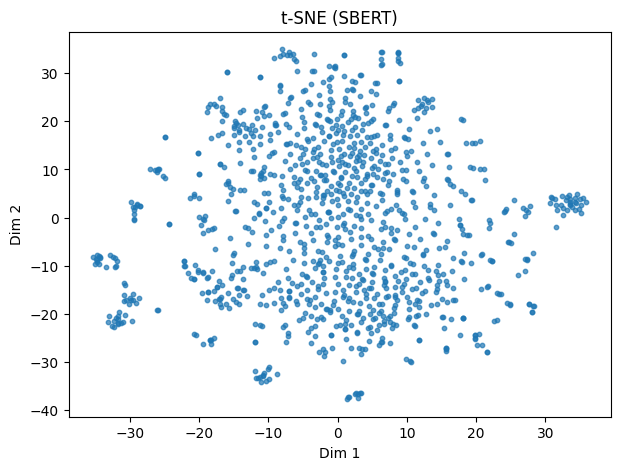

In [10]:
tsne_sbert = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
sbert_2d = tsne_sbert.fit_transform(embedding_sbert)

plt.figure(figsize=(7, 5))
plt.scatter(sbert_2d[:, 0], sbert_2d[:, 1], s=10, alpha=0.7)
plt.title("t-SNE (SBERT)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

### GoogleEmbedding + FAISS

In [11]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
import faiss
import numpy as np
import os
from dotenv import load_dotenv

load_dotenv()

# 1. Google Generative AI embedding nesnesini oluştur
model_google = GoogleGenerativeAIEmbeddings(model= "models/embedding-001")

embedding_google = [model_google.embed_query(chunk) for chunk in all_chunks_tr]

# 3. Listeyi numpy array haline getir, FAISS float32 ister
embedding_google_np = np.array(embedding_google).astype('float32')

# 4. FAISS index oluştur (dim embedding boyutuna göre)
dimension_google = embedding_google_np.shape[1]
index_google = faiss.IndexFlatL2(dimension_google)

# 5. Vektörleri indexe ekle
index_google.add(embedding_google_np)

c:\Anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


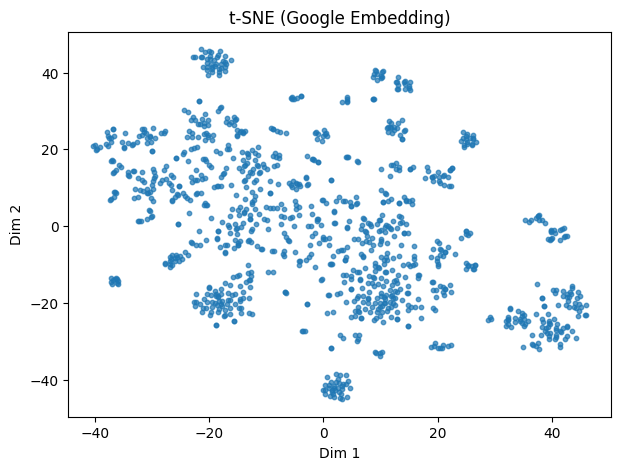

In [12]:
tsne_google = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
google_2d = tsne_google.fit_transform(np.array(embedding_google))

plt.figure(figsize=(7, 5))
plt.scatter(google_2d[:, 0], google_2d[:, 1], s=10, alpha=0.7)
plt.title("t-SNE (Google Embedding)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

### Query for TF-IDF

In [13]:
query = "Bilgisayar nedir?"
query_vec = vectorizer.transform([query]).toarray().astype('float32')

k = 5  # en yakın 5 sonucu getir
distances, indices = index_tfidf.search(query_vec, k)

print(f"En yakın {k} sonuç indeksleri: {indices}")
print(f"Mesafeler: {distances}")

for rank, idx in enumerate(indices[0], 1):
    chunk_text = all_chunks_tr[idx]
    first_100_words = ' '.join(chunk_text.split()[:100])
    print(f"\nRank {rank} - Index {idx} - Mesafe {distances[0][rank-1]:.4f}")
    print(first_100_words)

En yakın 5 sonuç indeksleri: [[ 213  212  778  779 1056]]
Mesafeler: [[0.8436943 1.141102  1.2441659 1.254559  1.4121766]]

Rank 1 - Index 213 - Mesafe 0.8437
Bölümü Bilgisayar destekli eğitim Bilgisayar destekli modelleme Bilgisayar destekli çeviri Bilgisayar destekli dil eğitimi Bilgisayar destekli yolcu ön tarama sistemi Bilgisayar destekli grafik-tasarım Bilgisayar grafikleri Bilgisayar grafiklerinde boyama teknikleri ( Phong yansıma modeli ) Bilgisayar öğretmenliği Bilgisayar ağı Bilgisayar animasyonu Bilgisayar oyunu Bilgisayar donanımı Bilgisayar donanımı tarihi Bilgisayarlı kimya Bilgisayarlı dilbilim Bilgisayarlı cebir sistemi Bilgisayarlı temografi Bilgisayar organizasyonu Kişisel bilgisayar Dizüstü bilgisayar Bilgisayar terminali Bilgisayar monitörü Bilgisayar dosyası Bilgisayar kümesi Yol bilgisayarı Kuantum bilgisayarı İnsan-bilgisayar etkileşimi Bilgisayar simülasyonu Bilgisayar soğutma Bilgisayarın zaman çizelgesi Kişisel bilgisayar satıcılarının pazar payı Bilgisayar sa

### Query for SBERT

In [14]:
query_text = "Bilgisayar nedir?"

query_embedding = model_sbert.encode(query_text).reshape(1, -1).astype('float32')

k = 5  # En yakın 5 sonucu getir
distances, indices = index_sbert.search(query_embedding, k)

print("Sorgu chunk:", query_text)
print("\nEn yakın chunklar:")
for i, idx in enumerate(indices[0]):
    print(f"Rank {i+1}, mesafe: {distances[0][i]:.4f}, metin: {all_chunks_tr[idx][:100]}...")

Sorgu chunk: Bilgisayar nedir?

En yakın chunklar:
Rank 1, mesafe: 0.8774, metin: ( enflasyon için düzeltilmiş ) ifade edilen gerçek GSYİH ekonominin veya nominal değerlerle ( enflas...
Rank 2, mesafe: 0.8843, metin: Amerikalı avukatlar...
Rank 3, mesafe: 0.8891, metin: düzenlenen Bolşevik Konferansında Bogdanov eleştirilir ve Bolşevik saflarından atılır . 1910 Partini...
Rank 4, mesafe: 0.8895, metin: Kitap İnsandır Sosyalizmin Çözülüþü Üzerine Üç Makale Faşizm ve Burjuva Demokrasisi Sosyalizm Nedir ...
Rank 5, mesafe: 0.8965, metin: . Değişik filozoflar temel varlık kategorileri için değişik listeler yapmışlardır . Ontolojinin teme...


C:\Users\Sadık\AppData\Roaming\Python\Python312\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


### Query for GoogleEmbedding

In [15]:
query = "Bilgisayar nedir?"
query_vec = model_google.embed_query(query)
query_vec = np.array(query_vec).astype('float32').reshape(1, -1)

k = 5
distances, indices = index_google.search(query_vec, k)

print(f"En yakın {k} sonuç indeksleri: {indices}")
print(f"Mesafeler: {distances}")

for rank, idx in enumerate(indices[0], 1):
    chunk_text = all_chunks_tr[idx]
    first_100_words = ' '.join(chunk_text.split()[:100])
    print(f"\nRank {rank} - Index {idx} - Mesafe {distances[0][rank-1]:.4f}")
    print(first_100_words)

En yakın 5 sonuç indeksleri: [[777 795 204 780 213]]
Mesafeler: [[0.40338373 0.41359913 0.44863474 0.46263474 0.4655333 ]]

Rank 1 - Index 777 - Mesafe 0.4034
Bilgisayar programcılığı , söz dizimi ve anlamı tanımlanmış bir kurallar bütününü olan programlama dillerini kullanarak ve bu şekilde sonlu sayıda komutu yazarak donanımına belli bir işi yaptırmaktır . Ayrıca bakınız Programlama dilleri Özgür yazılım Programlama Bilgisayar meslekleri

Rank 2 - Index 795 - Mesafe 0.4136
İller , Yerbilimi Kaynakça Ana madde konuları

Rank 3 - Index 204 - Mesafe 0.4486
Su Türk erkek şarkıcılar Türk halk müziği ses sanatçıları Türk sosyalistler Türk marksistler Türk opera şarkıcıları İstanbul'da kanserden ölenler Zincirlikuyu Mezarlığı'na defnedilenler Prostat kanserinden ölenler

Rank 4 - Index 780 - Mesafe 0.4626
, bilgisayar bilimi ve matematik ile yakından ilgilidir . Ayrıca bakınız Mühendislik Kontrol mühendisliği Elektronik ve haberleşme mühendisliği Yazılım mühendisliği Turing Ödülü Bilgisayar

### Cosine Similarity

#### TF-IDF

In [16]:
faiss.normalize_L2(tfidf_dense)

dimension_tfidf = tfidf_dense.shape[1]
index_tfidf = faiss.IndexFlatIP(dimension_tfidf)

index_tfidf.add(tfidf_dense)

print(f"TF-IDF FAISS indexinde toplam vektör sayısı: {index_tfidf.ntotal}")

TF-IDF FAISS indexinde toplam vektör sayısı: 1118


In [17]:
query = "Bilgisayar nedir?"

# 1. TF-IDF vektörünü çıkar
query_vec = vectorizer.transform([query]).toarray().astype('float32')

# 2. Normalize et
faiss.normalize_L2(query_vec)

# 3. Arama yap
k = 5
scores, indices = index_tfidf.search(query_vec, k)

print(f"En yakın {k} sonuç indeksleri: {indices}")
print(f"Benzerlik skorları (Cosine similarity): {scores}")

for rank, idx in enumerate(indices[0], 1):
    chunk_text = all_chunks_tr[idx]
    first_100_words = ' '.join(chunk_text.split()[:100])
    print(f"\nRank {rank} - Index {idx} - Skor {scores[0][rank-1]:.4f}")
    print(first_100_words)

En yakın 5 sonuç indeksleri: [[ 213  212  778  779 1056]]
Benzerlik skorları (Cosine similarity): [[0.57815284 0.429449   0.37791708 0.37272057 0.2939117 ]]

Rank 1 - Index 213 - Skor 0.5782
Bölümü Bilgisayar destekli eğitim Bilgisayar destekli modelleme Bilgisayar destekli çeviri Bilgisayar destekli dil eğitimi Bilgisayar destekli yolcu ön tarama sistemi Bilgisayar destekli grafik-tasarım Bilgisayar grafikleri Bilgisayar grafiklerinde boyama teknikleri ( Phong yansıma modeli ) Bilgisayar öğretmenliği Bilgisayar ağı Bilgisayar animasyonu Bilgisayar oyunu Bilgisayar donanımı Bilgisayar donanımı tarihi Bilgisayarlı kimya Bilgisayarlı dilbilim Bilgisayarlı cebir sistemi Bilgisayarlı temografi Bilgisayar organizasyonu Kişisel bilgisayar Dizüstü bilgisayar Bilgisayar terminali Bilgisayar monitörü Bilgisayar dosyası Bilgisayar kümesi Yol bilgisayarı Kuantum bilgisayarı İnsan-bilgisayar etkileşimi Bilgisayar simülasyonu Bilgisayar soğutma Bilgisayarın zaman çizelgesi Kişisel bilgisayar satıcı

#### SBERT

In [18]:
faiss.normalize_L2(embedding_sbert)

dimension_sbert = embedding_sbert.shape[1]

index_sbert = faiss.IndexFlatIP(dimension_sbert)

index_sbert.add(embedding_sbert)

print(f"SBERT FAISS indexinde toplam vektör sayısı: {index_sbert.ntotal}")

SBERT FAISS indexinde toplam vektör sayısı: 1118


In [19]:
query = "Bilgisayar nedir?"

query_vec = model_sbert.encode([query])
query_vec = np.array(query_vec).astype('float32')

faiss.normalize_L2(query_vec)

k = 5
scores, indices = index_sbert.search(query_vec, k)

print(f"En yakın {k} sonuç indeksleri: {indices}")
print(f"Benzerlik skorları (Cosine similarity): {scores}")

for rank, idx in enumerate(indices[0], 1):
    chunk_text = all_chunks_tr[idx]
    first_100_words = ' '.join(chunk_text.split()[:100])
    print(f"\nRank {rank} - Index {idx} - Skor {scores[0][rank-1]:.4f}")
    print(first_100_words)


En yakın 5 sonuç indeksleri: [[ 359  922  100  207 1056]]
Benzerlik skorları (Cosine similarity): [[0.56128764 0.5578309  0.5554286  0.5552385  0.5517259 ]]

Rank 1 - Index 359 - Skor 0.5613
( enflasyon için düzeltilmiş ) ifade edilen gerçek GSYİH ekonominin veya nominal değerlerle ( enflasyon için düzeltilmemiş ) ifade edilen ölçülerini birbirinden ayırır . Kaynakça Fransızcadan Türkçeye geçen sözcükler Ana madde konuları Sosyal bilimler

Rank 2 - Index 922 - Skor 0.5578
Amerikalı avukatlar

Rank 3 - Index 100 - Skor 0.5554
düzenlenen Bolşevik Konferansında Bogdanov eleştirilir ve Bolşevik saflarından atılır . 1910 Partinin ikiye bölünmüş olması ve Çarlık rejiminin yoğun baskısı , güçleri yeniden birleştirme yanlılarını harekete geçirir . Ocak 1910 ’ da Bolşevikler , Otozovistler ve çok sayıda Menşevik grup Paris ’ de Merkez Komite toplantısı yaparlar . Kamenev ve Zinoviev birleşme gündemine karşı olsalar da Viktor Nogin gibi arabulucu Bolşeviklerin ısrarına boyun eğerler . Lenin birl

#### Google Embedding

In [20]:
faiss.normalize_L2(embedding_google_np)

dimension = embedding_google_np.shape[1]
index_google = faiss.IndexFlatIP(dimension)

index_google.add(embedding_google_np)

In [21]:
query = "Bilgisayar nedir?"
query_vec = model_google.embed_query(query)
query_vec = np.array(query_vec).astype('float32').reshape(1, -1)

faiss.normalize_L2(query_vec)

k = 5
scores, indices = index_google.search(query_vec, k)

print(f"En yakın {k} sonuç indeksleri: {indices}")
print(f"Benzerlik skorları (Cosine similarity): {scores}")

for rank, idx in enumerate(indices[0], 1):
    chunk_text = all_chunks_tr[idx]
    first_100_words = ' '.join(chunk_text.split()[:100])
    print(f"\nRank {rank} - Index {idx} - Benzerlik skoru {scores[0][rank-1]:.4f}")
    print(first_100_words)

En yakın 5 sonuç indeksleri: [[777 795 204 780 213]]
Benzerlik skorları (Cosine similarity): [[0.7983073  0.79319996 0.7756819  0.76868176 0.7672321 ]]

Rank 1 - Index 777 - Benzerlik skoru 0.7983
Bilgisayar programcılığı , söz dizimi ve anlamı tanımlanmış bir kurallar bütününü olan programlama dillerini kullanarak ve bu şekilde sonlu sayıda komutu yazarak donanımına belli bir işi yaptırmaktır . Ayrıca bakınız Programlama dilleri Özgür yazılım Programlama Bilgisayar meslekleri

Rank 2 - Index 795 - Benzerlik skoru 0.7932
İller , Yerbilimi Kaynakça Ana madde konuları

Rank 3 - Index 204 - Benzerlik skoru 0.7757
Su Türk erkek şarkıcılar Türk halk müziği ses sanatçıları Türk sosyalistler Türk marksistler Türk opera şarkıcıları İstanbul'da kanserden ölenler Zincirlikuyu Mezarlığı'na defnedilenler Prostat kanserinden ölenler

Rank 4 - Index 780 - Benzerlik skoru 0.7687
, bilgisayar bilimi ve matematik ile yakından ilgilidir . Ayrıca bakınız Mühendislik Kontrol mühendisliği Elektronik ve hab